In [1]:
import pandas as pd

In [2]:
dim_date=pd.read_csv('https://raw.githubusercontent.com/RitikOnTheRoad/Optimizing-Revenue-Leakage-Profitability-in-the-Hospitality-Sector/refs/heads/main/Raw%20datasets/dim_date.csv')
dim_hotel=pd.read_csv("https://raw.githubusercontent.com/RitikOnTheRoad/Optimizing-Revenue-Leakage-Profitability-in-the-Hospitality-Sector/refs/heads/main/Raw%20datasets/dim_hotels.csv")
dim_rooms=pd.read_csv("https://raw.githubusercontent.com/RitikOnTheRoad/Optimizing-Revenue-Leakage-Profitability-in-the-Hospitality-Sector/refs/heads/main/Raw%20datasets/dim_rooms.csv")
fact_bookings=pd.read_csv("https://raw.githubusercontent.com/RitikOnTheRoad/Optimizing-Revenue-Leakage-Profitability-in-the-Hospitality-Sector/refs/heads/main/Raw%20datasets/fact_bookings.csv")
fact_aggregated_bookings=pd.read_csv("https://raw.githubusercontent.com/RitikOnTheRoad/Optimizing-Revenue-Leakage-Profitability-in-the-Hospitality-Sector/refs/heads/main/Raw%20datasets/fact_aggregated_bookings.csv")

In [4]:
dim_hotel.property_name.value_counts()

,count
property_name,
Atliq Grands,4
Atliq Exotica,4
Atliq City,4
Atliq Blu,4
Atliq Bay,4
Atliq Palace,4
Atliq Seasons,1


In [3]:
dim_date.head()

,date,mmm yy,week no,day_type
0,01-May-22,May 22,W 19,weekend
1,02-May-22,May 22,W 19,weekeday
2,03-May-22,May 22,W 19,weekeday
3,04-May-22,May 22,W 19,weekeday
4,05-May-22,May 22,W 19,weekeday


In [4]:
print(dim_date.dtypes)
print(dim_date.shape)
print(dim_date.info()) #no null values

date        object
mmm yy      object
week no     object
day_type    object
dtype: object
(92, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      92 non-null     object
 1   mmm yy    92 non-null     object
 2   week no   92 non-null     object
 3   day_type  92 non-null     object
dtypes: object(4)
memory usage: 3.0+ KB
None


In [5]:
dim_hotel.head()

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi
1,16559,Atliq Exotica,Luxury,Mumbai
2,16560,Atliq City,Business,Delhi
3,16561,Atliq Blu,Luxury,Delhi
4,16562,Atliq Bay,Luxury,Delhi


In [6]:
print(dim_hotel.info())
print(dim_hotel.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   property_id    25 non-null     int64 
 1   property_name  25 non-null     object
 2   category       25 non-null     object
 3   city           25 non-null     object
dtypes: int64(1), object(3)
memory usage: 932.0+ bytes
None
(25, 4)


In [7]:
print(dim_rooms.head())
print(dim_rooms.shape)
print(dim_rooms.info())

  room_id    room_class
0     RT1      Standard
1     RT2         Elite
2     RT3       Premium
3     RT4  Presidential
(4, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   room_id     4 non-null      object
 1   room_class  4 non-null      object
dtypes: object(2)
memory usage: 196.0+ bytes
None


In [8]:
fact_bookings.head()

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,2022-04-27,2022-05-01,2022-05-02,3,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,2022-04-30,2022-05-01,2022-05-02,2,RT1,others,NaN,Cancelled,9100,3640
2,May012216558RT13,16558,2022-04-28,2022-05-01,2022-05-04,2,RT1,logtrip,5.0,Checked Out,9100,9100
3,May012216558RT14,16558,2022-04-28,2022-05-01,2022-05-02,2,RT1,others,NaN,Cancelled,9100,3640
4,May012216558RT15,16558,2022-04-27,2022-05-01,2022-05-02,4,RT1,direct online,5.0,Checked Out,10920,10920


In [9]:
print(fact_bookings.info())
print(fact_bookings.shape) #ratings_given has null values.
print("Percentage of missing reviews: ",fact_bookings.ratings_given.isna().sum()/fact_bookings.shape[0]*100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134590 entries, 0 to 134589
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   booking_id         134590 non-null  object 
 1   property_id        134590 non-null  int64  
 2   booking_date       134590 non-null  object 
 3   check_in_date      134590 non-null  object 
 4   checkout_date      134590 non-null  object 
 5   no_guests          134590 non-null  int64  
 6   room_category      134590 non-null  object 
 7   booking_platform   134590 non-null  object 
 8   ratings_given      56683 non-null   float64
 9   booking_status     134590 non-null  object 
 10  revenue_generated  134590 non-null  int64  
 11  revenue_realized   134590 non-null  int64  
dtypes: float64(1), int64(4), object(7)
memory usage: 12.3+ MB
None
(134590, 12)
Percentage of missing reviews:  57.884686826658736


In [10]:
fact_aggregated_bookings.head()

,property_id,check_in_date,room_category,successful_bookings,capacity
0,16559,01-May-22,RT1,25,30
1,19562,01-May-22,RT1,28,30
2,19563,01-May-22,RT1,23,30
3,17558,01-May-22,RT1,13,19
4,16558,01-May-22,RT1,18,19


In [11]:
print(fact_aggregated_bookings.info())
print(fact_aggregated_bookings.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9200 entries, 0 to 9199
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   property_id          9200 non-null   int64 
 1   check_in_date        9200 non-null   object
 2   room_category        9200 non-null   object
 3   successful_bookings  9200 non-null   int64 
 4   capacity             9200 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 359.5+ KB
None
(9200, 5)


In [12]:
#How many unique properties?
print("Number of unique hotels:",dim_hotel['property_id'].nunique())

Number of unique hotels: 25


In [13]:
#Does for any date there is more booking than capacity?
fact_aggregated_bookings.query("successful_bookings >capacity") #no wrong entry

,property_id,check_in_date,room_category,successful_bookings,capacity


In [14]:
#changing data type of date columns
fact_bookings['booking_date']=pd.to_datetime(fact_bookings['booking_date'])
fact_bookings["check_in_date"]=pd.to_datetime(fact_bookings["check_in_date"])
fact_bookings["checkout_date"]=pd.to_datetime(fact_bookings["checkout_date"])

fact_aggregated_bookings['check_in_date']=pd.to_datetime(fact_aggregated_bookings['check_in_date'])

/tmp/ipython-input-14-210207500.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  fact_aggregated_bookings['check_in_date']=pd.to_datetime(fact_aggregated_bookings['check_in_date'])


In [15]:
#Adding flag for if user has left a rating.
fact_bookings["has_rated"]=fact_bookings["ratings_given"].map(lambda x: 1 if x>0 else 0)

In [16]:
#How many types of booking platforms?
fact_bookings.booking_platform.value_counts().sort_values()


,count
booking_platform,
direct offline,6755
journey,8106
tripster,9630
direct online,13379
logtrip,14756
makeyourtrip,26898
others,55066


In [17]:
#Types of booking status?
fact_bookings.booking_status.value_counts()

,count
booking_status,
Checked Out,94411
Cancelled,33420
No Show,6759


In [18]:
#Revenue leakage
fact_bookings["revenue_leakage"]=fact_bookings.revenue_generated.sub(fact_bookings.revenue_realized)

In [19]:
#Occupancy percentage
fact_aggregated_bookings["occupancy_percentage"]=fact_aggregated_bookings["successful_bookings"].div(fact_aggregated_bookings["capacity"])*100

In [20]:
fact_aggregated_bookings.head()

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy_percentage
0,16559,2022-05-01,RT1,25,30,83.333333
1,19562,2022-05-01,RT1,28,30,93.333333
2,19563,2022-05-01,RT1,23,30,76.666667
3,17558,2022-05-01,RT1,13,19,68.421053
4,16558,2022-05-01,RT1,18,19,94.736842


In [21]:
fact_aggregated_bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9200 entries, 0 to 9199
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   property_id           9200 non-null   int64         
 1   check_in_date         9200 non-null   datetime64[ns]
 2   room_category         9200 non-null   object        
 3   successful_bookings   9200 non-null   int64         
 4   capacity              9200 non-null   int64         
 5   occupancy_percentage  9200 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 431.4+ KB


In [22]:
fact_aggregated_bookings["check_in_day"]=fact_aggregated_bookings["check_in_date"].dt.day_name()
fact_aggregated_bookings["check_in_month"]=fact_aggregated_bookings["check_in_date"].dt.month_name()

In [23]:
#date range of data
print("Start date:",fact_aggregated_bookings["check_in_date"].min())
print("End date:",fact_aggregated_bookings["check_in_date"].max())
print("Date range:",fact_aggregated_bookings["check_in_date"].max()-fact_aggregated_bookings["check_in_date"].min())

Start date: 2022-05-01 00:00:00
End date: 2022-07-31 00:00:00
Date range: 91 days 00:00:00


In [24]:
print(fact_bookings.shape)
fact_aggregated_bookings.shape

(134590, 14)


(9200, 8)

In [25]:
import plotly.express as px

In [26]:
fact_aggregated_bookings.head(1)

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy_percentage,check_in_day,check_in_month
0,16559,2022-05-01,RT1,25,30,83.333333,Sunday,May


Eda


In [27]:
#Total bookings over time
successful_bookings_df=fact_aggregated_bookings.groupby("check_in_date")["successful_bookings"].sum()
fig=px.line(data_frame=successful_bookings_df,x=successful_bookings_df.index,y=successful_bookings_df.values,title="Total successful bookings over time")
fig.update_layout(xaxis_title="Date",yaxis_title="Total successful bookings")
fig.update_xaxes(tickangle=45)

fig.show()

#Line chart shows spikes on weekends and sudden fall on weekdays for the number of bookings.

In [28]:
booking_by_day_df=fact_aggregated_bookings.groupby("check_in_day")["successful_bookings"].mean().sort_values()
fig=px.bar(data_frame=booking_by_day_df,y=booking_by_day_df.index,x=booking_by_day_df.values,
           title="Average successful bookings by day",orientation="h",color=range(7),
           )
fig.update_layout(yaxis_title="Day",xaxis_title="Average successful bookings",coloraxis_showscale=False)
fig.update_xaxes(tickangle=45)

In [29]:
#Does weekends have higher average booking than weekdays
#H0:Bookings on weekdays and weekends come from the same distributions
#H1:Weekend bookings are generally higher

weekend_df=fact_aggregated_bookings.query("check_in_day in ['Saturday','Sunday']").successful_bookings
weekday_df=fact_aggregated_bookings.query("check_in_day not in ['Saturday','Sunday']").successful_bookings

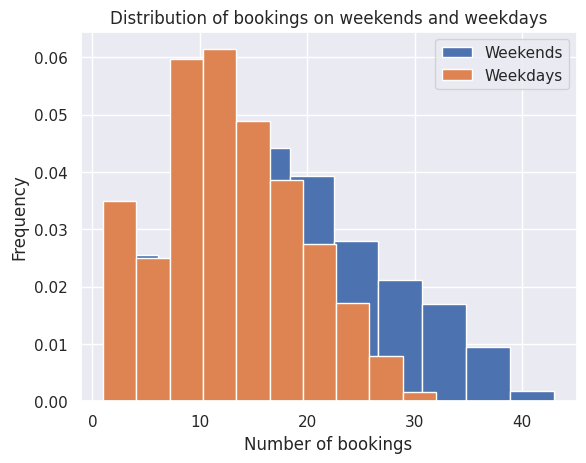

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
plt.hist(weekend_df,density=True)
plt.hist(weekday_df,density=True)

plt.legend(["Weekends","Weekdays"])
plt.xlabel("Number of bookings")
plt.ylabel("Frequency")
plt.title("Distribution of bookings on weekends and weekdays")
plt.show()

#data is skewed so we use mann-whitney u test.

In [31]:
from scipy.stats import mannwhitneyu
stat,p=mannwhitneyu(weekend_df,weekday_df)
print("stat:",stat)
print("p:",p)

#Test confirms that weekend bookings are higher than weekend bookings

stat: 12109530.0
p: 4.8812434958833994e-182


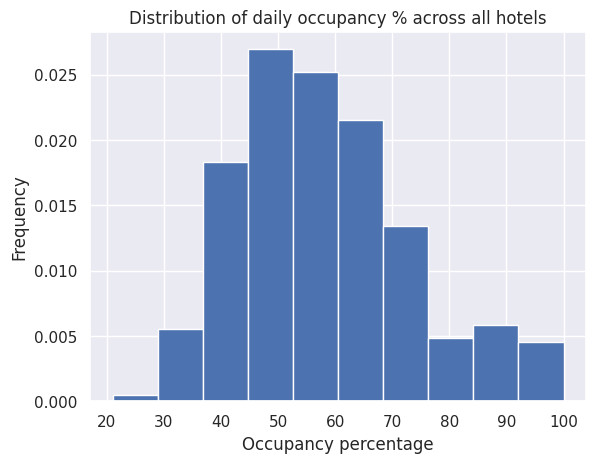

In [32]:
#Distribution of daily occupancy % across all hotels
plt.hist(fact_aggregated_bookings.occupancy_percentage,density=True)
plt.xlabel("Occupancy percentage")
plt.ylabel("Frequency")
plt.title("Distribution of daily occupancy % across all hotels")
plt.show()

In [33]:
dim_hotel.head(1)

,property_id,property_name,category,city
0,16558,Atliq Grands,Luxury,Delhi


In [34]:
#Top 5 hotels by average occupancy
top_five=fact_aggregated_bookings.groupby("property_id")[["occupancy_percentage"]].mean().sort_values(by="occupancy_percentage",ascending=False).head(5)
bottom_five=fact_aggregated_bookings.groupby("property_id")[["occupancy_percentage"]].mean().sort_values(by="occupancy_percentage",ascending=False).tail(5)

top_five=top_five.merge(dim_hotel,on="property_id")
bottom_five=bottom_five.merge(dim_hotel,on="property_id")

In [35]:
top_five["property_and_location"]=top_five["property_name"]+", "+top_five["city"]
bottom_five["property_and_location"]=bottom_five["property_name"]+", "+bottom_five["city"]


In [36]:
top_five.rename(columns={"occupancy_percentage":"average_occupancy_percentage"},inplace=True)
bottom_five.rename(columns={"occupancy_percentage":"average_occupancy_percentage"},inplace=True)

In [37]:
dim_hotel["property_with_city"]=dim_hotel["property_name"]+", "+dim_hotel["city"]

In [38]:
print(top_five[["property_and_location","average_occupancy_percentage"]])
print(bottom_five[["property_and_location","average_occupancy_percentage"]])

   property_and_location  average_occupancy_percentage
0      Atliq Blu, Mumbai                     68.273784
1    Atliq Grands, Delhi                     67.697823
2  Atliq City, Hyderabad                     66.376812
3    Atliq Palace, Delhi                     66.351901
4  Atliq Exotica, Mumbai                     66.203130
      property_and_location  average_occupancy_percentage
0        Atliq City, Mumbai                     52.938278
1         Atliq Bay, Mumbai                     45.473531
2   Atliq Grands, Bangalore                     44.887646
3  Atliq Exotica, Hyderabad                     44.718022
4     Atliq Seasons, Mumbai                     44.506407


In [39]:
fact_aggregated_bookings=fact_aggregated_bookings.merge(dim_hotel[["property_id","property_with_city","category"]],on="property_id")

In [40]:
fact_aggregated_bookings.head(1)

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy_percentage,check_in_day,check_in_month,property_with_city,category
0,16559,2022-05-01,RT1,25,30,83.333333,Sunday,May,"Atliq Exotica, Mumbai",Luxury


In [41]:
#Platform rating %
platform_rating_df=fact_bookings.groupby("booking_platform")["has_rated"].mean()*100
platform_rating_df

,has_rated
booking_platform,
direct offline,41.998520
direct online,41.968757
journey,42.758451
logtrip,42.389536
makeyourtrip,42.051454
others,42.013220
tripster,42.201454


In [42]:
fact_bookings.head(1)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,has_rated,revenue_leakage
0,May012216558RT11,16558,2022-04-27,2022-05-01,2022-05-02,3,RT1,direct online,1.0,Checked Out,10010,10010,1,0


In [43]:
fact_bookings.booking_status.unique()

array(['Checked Out', 'Cancelled', 'No Show'], dtype=object)

In [44]:
fact_bookings.query("booking_status=='No Show' & revenue_leakage>0") #Theres no revenue leakage if booking_status is No show.

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,has_rated,revenue_leakage


In [45]:
fact_bookings.query("booking_status=='Cancelled' & revenue_leakage==0") #Theres always revenue leakage if booking is cancelled.

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,has_rated,revenue_leakage


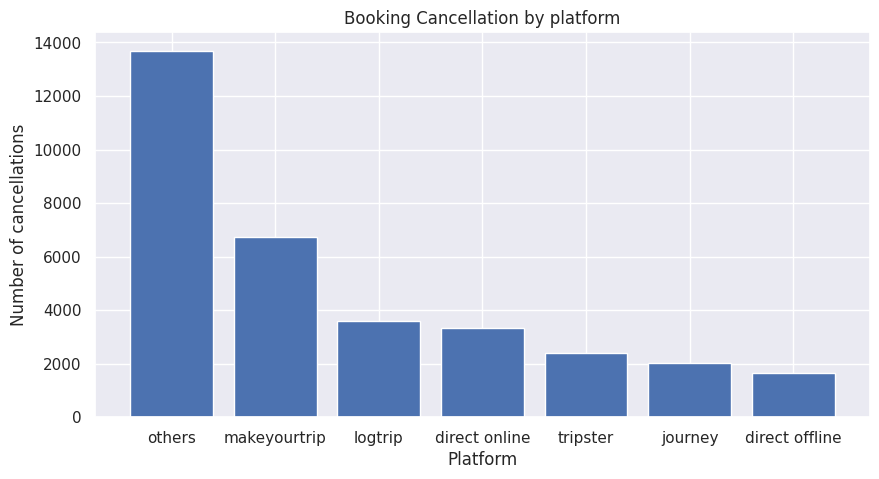

In [46]:
#Which platfrom contributes to most Cancellation.
plt.figure(figsize=(10,5))
plt.bar(x=fact_bookings.query("booking_status=='Cancelled'").booking_platform.value_counts().index,
        height=fact_bookings.query("booking_status=='Cancelled'").booking_platform.value_counts(),
        )
plt.title("Booking Cancellation by platform")
plt.xlabel("Platform")
plt.ylabel("Number of cancellations")
plt.show()
#Number of cancellations is directly prorportional to revenue leakage

KPIs


In [47]:
#Total Rvenue
total_revenue=fact_bookings.groupby("property_id").revenue_realized.sum()

In [48]:
#Average Daily Rate(kpi)
import numpy as np
total_sucessful_booking=fact_aggregated_bookings.groupby("property_id")['successful_bookings'].sum()
total_revenue_realized=fact_bookings.groupby("property_id")["revenue_realized"].sum()
adr=round(np.divide(total_revenue_realized,total_sucessful_booking),2)


In [49]:
#RevPar
total_capacity=fact_aggregated_bookings.groupby("property_id")["capacity"].sum()
revpar=round(np.divide(total_revenue_realized,total_capacity),2)


In [50]:
#alos
total_bookings=fact_bookings.query("booking_status=='Checked Out'").groupby("property_id")['booking_id'].count()
alos=round(np.divide(total_sucessful_booking,total_bookings),2)


In [51]:
#average ratings
avg_rating=fact_bookings.query("has_rated==1").groupby("property_id")["ratings_given"].mean()

In [52]:
#Booking % by room type
temp=fact_bookings.groupby(["property_id","room_category"])["booking_id"].count().unstack()
booking_perc_by_room_type=round(temp.divide(temp.sum(axis=1),axis=0)*100,2)


In [53]:
#Revenue realised % by room type
temp=fact_bookings.groupby(["property_id","room_category"])["revenue_realized"].sum().unstack()
revenue_perc_by_room_type=round(temp.divide(temp.sum(axis=1),axis=0)*100,2)


In [54]:
#cancellatiion %
cancellation_perc=round(fact_bookings.query("booking_status=='Cancelled'").groupby("property_id")["booking_id"].count()/fact_bookings.groupby("property_id")["booking_id"].count()*100,2)

In [55]:
#No show rate
no_show_rate=round(fact_bookings.query("booking_status=='No Show'").groupby("property_id")["booking_id"].count()/fact_bookings.groupby("property_id")["booking_id"].count()*100,2)

In [56]:
#Occupancy percentage
occupancy_percentage=round(fact_aggregated_bookings.groupby("property_id")["occupancy_percentage"].mean(),2)

In [57]:
#merging all kpis
kpi_df=pd.concat([total_revenue,adr,revpar,alos,avg_rating,booking_perc_by_room_type,revenue_perc_by_room_type,cancellation_perc,no_show_rate,occupancy_percentage],axis=1)


In [58]:
column_list=kpi_df.columns.values
column_list[1]="adr"
column_list[2]="revpar"
column_list[3]="alos"
column_list[4]="average_ratings"
column_list[-2]="no_show_rate"
column_list[-3]="cancellation_rate"
column_list[5]="booking_perc_RT1"
column_list[6]="booking_perc_RT2"
column_list[7]="booking_perc_RT3"
column_list[8]="booking_perc_RT4"
column_list[9]="revenue_perc_RT1"
column_list[10]="revenue_perc_RT2"
column_list[11]="revenue_perc_RT3"
column_list[12]="revenue_perc_RT4"
kpi_df.columns=column_list

In [59]:
kpi_df.head(2)

,revenue_realized,adr,revpar,alos,average_ratings,booking_perc_RT1,booking_perc_RT2,booking_perc_RT3,booking_perc_RT4,revenue_perc_RT1,revenue_perc_RT2,revenue_perc_RT3,revenue_perc_RT4,cancellation_rate,no_show_rate,occupancy_percentage
property_id,,,,,,,,,,,,,,,,
16558,36061172,11437.10,7537.87,1.43,4.250939,36.22,42.06,15.16,6.57,25.14,40.80,20.10,13.97,25.06,4.92,67.70
16559,118448418,16141.78,10640.35,1.42,4.324544,25.01,33.59,26.51,14.90,14.96,28.15,29.98,26.92,24.61,5.01,65.98


In [60]:
#Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [61]:
X_scaled=StandardScaler().fit_transform(kpi_df)

In [62]:
clustrer=KMeans(n_clusters=3,random_state=42)
clustrer.fit(X_scaled)

KMeans(n_clusters=3, random_state=42)

In [63]:
kpi_df["cluster"]=clustrer.labels_

In [64]:
kpi_df.cluster.value_counts()

,count
cluster,
0,12
2,9
1,4


In [65]:
#cluster validation
from sklearn.metrics import silhouette_score
ss=silhouette_score(X_scaled,clustrer.labels_)
print("The score is:",ss)

The score is: 0.19137442339190122


In [66]:
#PCA on dataset
from sklearn.decomposition import PCA
pca=PCA(n_components=0.8)
X_pca=pca.fit_transform(X_scaled)

In [67]:
result=pca.fit(X_scaled)
sum(result.explained_variance_ratio_)

np.float64(0.8712026950629583)

In [68]:
pca_cluster=KMeans(n_clusters=3,random_state=42)
pca_cluster.fit(X_pca)

KMeans(n_clusters=3, random_state=42)

In [69]:
ss=silhouette_score(X_pca,pca_cluster.labels_)
print("The score is:",ss)

The score is: 0.2367630625488874


###WoW Analysis

## Root Cause Analysis

In [70]:
lowest_performing=kpi_df.sort_values(by="revenue_realized").head(1)
lowest_performing

,revenue_realized,adr,revpar,alos,average_ratings,booking_perc_RT1,booking_perc_RT2,booking_perc_RT3,booking_perc_RT4,revenue_perc_RT1,revenue_perc_RT2,revenue_perc_RT3,revenue_perc_RT4,cancellation_rate,no_show_rate,occupancy_percentage,cluster
property_id,,,,,,,,,,,,,,,,,
16558,36061172,11437.1,7537.87,1.43,4.250939,36.22,42.06,15.16,6.57,25.14,40.8,20.1,13.97,25.06,4.92,67.7,0


In [71]:
round(kpi_df.query("property_id != 16558").mean(),2) #average of combined.

,0
revenue_realized,69696252.38
adr,12779.03
revpar,7379.67
alos,1.43
average_ratings,3.50
booking_perc_RT1,28.06
booking_perc_RT2,36.89
booking_perc_RT3,23.23
booking_perc_RT4,11.82
revenue_perc_RT1,18.01


In [72]:
kpi_df.sort_values('revenue_realized').tail(1)

,revenue_realized,adr,revpar,alos,average_ratings,booking_perc_RT1,booking_perc_RT2,booking_perc_RT3,booking_perc_RT4,revenue_perc_RT1,revenue_perc_RT2,revenue_perc_RT3,revenue_perc_RT4,cancellation_rate,no_show_rate,occupancy_percentage,cluster
property_id,,,,,,,,,,,,,,,,,
16559,118448418,16141.78,10640.35,1.42,4.324544,25.01,33.59,26.51,14.9,14.96,28.15,29.98,26.92,24.61,5.01,65.98,2


In [73]:
dim_hotel.query("(property_id==16558) or (property_id==16559)")

,property_id,property_name,category,city,property_with_city
0,16558,Atliq Grands,Luxury,Delhi,"Atliq Grands, Delhi"
1,16559,Atliq Exotica,Luxury,Mumbai,"Atliq Exotica, Mumbai"


In [74]:
pd.set_option('display.float_format', '{:,.2f}'.format)

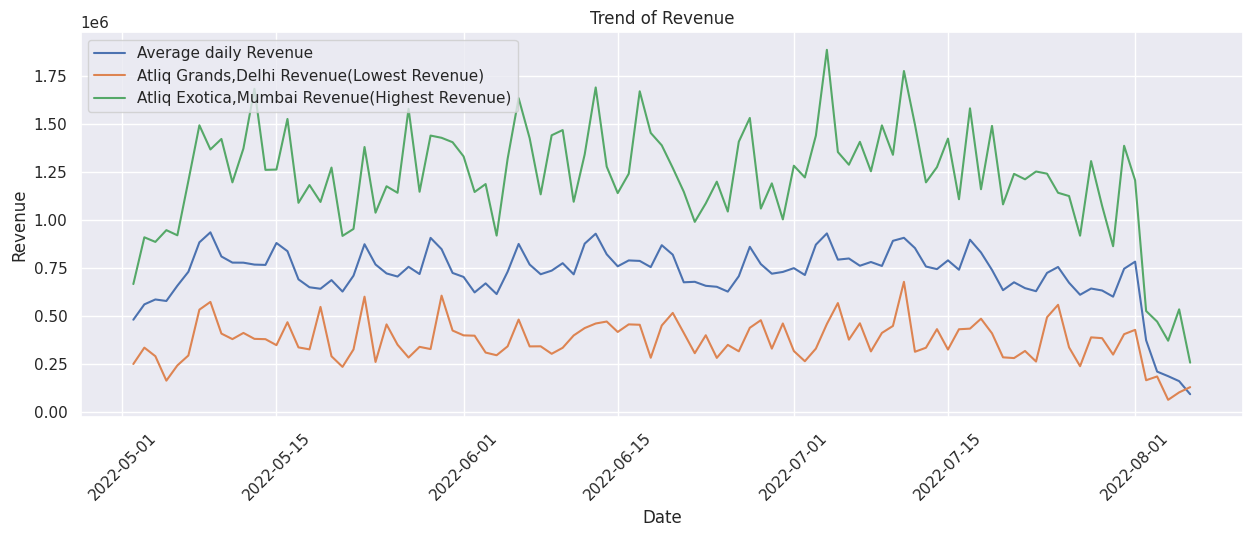

In [75]:
#trend of combined revenue vs revenue of 16558
combined_revenue_trend=fact_bookings.query("property_id != 16558").groupby("checkout_date")['revenue_realized'].sum()/24
lowest_revenue_trend=fact_bookings.query("property_id == 16558").groupby("checkout_date")['revenue_realized'].sum()
highest_revenue_trend=fact_bookings.query("property_id == 16559").groupby("checkout_date")['revenue_realized'].sum()

fig,ax=plt.subplots(figsize=(15,5))
ax=sns.lineplot(x=combined_revenue_trend.index,y=combined_revenue_trend.values,label="Average daily Revenue")
ax=sns.lineplot(x=lowest_revenue_trend.index,y=lowest_revenue_trend.values,label="Atliq Grands,Delhi Revenue(Lowest Revenue)")
ax=sns.lineplot(x=highest_revenue_trend.index,y=highest_revenue_trend.values,label="Atliq Exotica,Mumbai Revenue(Highest Revenue)")
ax.set_title("Trend of Revenue")
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
ax.tick_params(axis='x',rotation=45)
ax.legend()
plt.show()

fig.show()

In [76]:
#Number or rooms by room type
total_number_of_rooms_available=fact_aggregated_bookings.groupby(["property_id","room_category"])["capacity"].sum()
total_number_of_rooms_available=total_number_of_rooms_available.unstack()
print(total_number_of_rooms_available.head(2))

number_of_rooms_available_perday=total_number_of_rooms_available/92
number_of_rooms_available_perday.head(2)

room_category   RT1   RT2   RT3   RT4
property_id                          
16558          1748  2024   736   276
16559          2760  3772  2944  1656


room_category,RT1,RT2,RT3,RT4
property_id,,,,
16558,19.00,22.00,8.00,3.00
16559,30.00,41.00,32.00,18.00


In [77]:
#revenue
roomwise_revenue=fact_bookings.groupby(["property_id","room_category"])["revenue_generated"].sum().unstack()
roomtype_sold=fact_bookings.groupby(["property_id","room_category"])["booking_id"].count().unstack()
roomwise_adr=np.divide(roomwise_revenue,roomtype_sold)

expected_revenue=np.multiply(total_number_of_rooms_available,roomwise_adr)
expected_revenue["total"]=expected_revenue.sum(axis=1)
expected_revenue.head()

room_category,RT1,RT2,RT3,RT4,total
property_id,,,,,
16558,"16,539,171.91","26,389,021.90","12,936,477.99","7,674,986.67","63,539,658.47"
16559,"31,545,070.30","59,668,877.79","63,133,043.17","56,092,280.48","210,439,271.74"
16560,"29,162,170.84","40,444,251.43","32,246,195.74","17,831,644.44","119,684,262.45"
16561,"15,681,458.76","28,759,123.23","34,114,685.90","25,693,570.81","104,248,838.70"
16562,"26,940,493.62","51,590,077.49","29,241,044.15","15,457,490.93","123,229,106.19"


In [78]:
revenue_leakage=expected_revenue["total"]-kpi_df["revenue_realized"]
print("High reveue leakage\n",revenue_leakage.sort_values(ascending=False).head(3))
print("Lowest revenue leakage\n",revenue_leakage.sort_values(ascending=False).tail(1))

High reveue leakage
 property_id
17564   108,001,236.77
17560   107,614,781.56
16559    91,990,853.74
dtype: float64
Lowest revenue leakage
 property_id
16558   27,478,486.47
dtype: float64


In [79]:
#Hotels with highest revenue leakage
dim_hotel.query("(property_id==17564) or (property_id==17560)") #if we exlude these two hotels the revenue leakage does not have much variation
#so we analyse these hotels to reduce oveall variation.



,property_id,property_name,category,city,property_with_city
8,17560,Atliq City,Business,Mumbai,"Atliq City, Mumbai"
24,17564,Atliq Seasons,Business,Mumbai,"Atliq Seasons, Mumbai"


In [80]:
print("KPI of Least efficient Hotels\n",kpi_df.query("(property_id==17564) or (property_id==17560)").T)
print("KPI of Most efficient Hotel\n",kpi_df.query("property_id==16558").T)

KPI of Least efficient Hotels
 property_id                  17560         17564
revenue_realized     87,996,216.00 66,125,495.00
adr                      14,634.33     16,606.10
revpar                    7,776.27      7,409.85
alos                          1.44          1.42
average_ratings               3.04          2.29
booking_perc_RT1             32.28         16.25
booking_perc_RT2             36.94         41.34
booking_perc_RT3             20.47         25.11
booking_perc_RT4             10.31         17.30
revenue_perc_RT1             21.46          9.52
revenue_perc_RT2             33.50         33.41
revenue_perc_RT3             25.05         27.18
revenue_perc_RT4             19.99         29.89
cancellation_rate            25.06         24.79
no_show_rate                  5.39          4.62
occupancy_percentage         52.94         44.51
cluster                       0.00          1.00
KPI of Most efficient Hotel
 property_id                  16558
revenue_realized     36

In [81]:
#Relation between hotel type and revenue leakage.
#Relation between leakage and location.

In [82]:
#Hotel Type vs leakage
#Ho: No differnce in central tendency/rank of two groups.
#Mann whitney
temp=revenue_leakage.to_frame().reset_index()
temp.columns=["property_id","revenue_leakage"]
temp=temp.merge(dim_hotel[["property_id","category"]],on="property_id")
temp_luxury=temp.query("category=='Luxury'").revenue_leakage
temp_business=temp.query("category=='Business'").revenue_leakage
stat,p=mannwhitneyu(temp_luxury,temp_business)
print("stat:",stat)
print("p:",p)  ## non significant but group sizes are small.

stat: 61.0
p: 0.5522142220341504


In [83]:
#Leakage and location
#low group size- Proceede with caution
temp=temp.merge(dim_hotel[["property_id","city"]],on="property_id")
temp_delhi=temp.query("city=='Delhi'").revenue_leakage
temp_mumbai=temp.query("city=='Mumbai'").revenue_leakage
temp_heydrabad=temp.query("city=='Hyderabad'").revenue_leakage
temp_bangalore=temp.query("city=='Bangalore'").revenue_leakage

#Kruskal–Wallis test
#H0:All groups come from the same distribution (i.e., no difference in medians/ranks)
#H1:At least one group is different from the others

from scipy.stats import kruskal

stat,p=kruskal(temp_delhi,temp_mumbai,temp_heydrabad,temp_bangalore)
print("stat:",stat)
print("p:",p)

stat: 13.220769230769235
p: 0.004182707684133614


In [84]:
pip install scikit_posthocs

In [85]:
#Post hoc
import scikit_posthocs as sp
sp.posthoc_dunn([temp_delhi,temp_mumbai,temp_heydrabad,temp_bangalore])
#Group 2 has differnce between group 1, group 3
#So revenue leakage in mumbai is different than revenue leakage in other cities

,1,2,3,4
1,1.00,0.01,0.74,0.09
2,0.01,1.00,0.00,0.36
3,0.74,0.00,1.00,0.03
4,0.09,0.36,0.03,1.00


In [86]:
dim_hotel.city.value_counts()

,count
city,
Mumbai,8
Hyderabad,6
Bangalore,6
Delhi,5


In [87]:
#week on week analysis of reveunue leakage of 17564
temp=fact_bookings.query("property_id==17564")[["booking_id","check_in_date","revenue_generated","revenue_realized"]]
temp["week"]=temp["check_in_date"].dt.isocalendar().week

In [88]:
occupancy_capacity_by_week=fact_aggregated_bookings.query("property_id==17564")[['check_in_date','successful_bookings']]
occupancy_capacity_by_week["week"]=occupancy_capacity_by_week["check_in_date"].dt.isocalendar().week
occupancy_capacity_by_week=occupancy_capacity_by_week.groupby("week")[["successful_bookings"]].sum()
occupancy_capacity_by_week


weekly_revenues=temp.groupby("week")[["revenue_generated","revenue_realized"]].sum()
weekly_revenues=weekly_revenues.merge(occupancy_capacity_by_week,left_on="week",right_on=occupancy_capacity_by_week.index)
weekly_revenues

temp1=fact_aggregated_bookings.query("property_id==17564")[['check_in_date','capacity']]
temp1["week"]=temp1["check_in_date"].dt.isocalendar().week
temp1=temp1.groupby("week")[["capacity"]].sum()

weekly_revenues=weekly_revenues.merge(temp1,left_on="week",right_on=temp1.index)
weekly_revenues

weekly_revenues["adr"]=weekly_revenues["revenue_realized"]/weekly_revenues["successful_bookings"]
weekly_revenues["expected_revenue"]=weekly_revenues["capacity"]*weekly_revenues["adr"]
weekly_revenues["revenue_leakage"]=weekly_revenues["revenue_generated"]-weekly_revenues["revenue_realized"]

In [89]:
#week on week analysis of reveunue leakage of 17560
temp=fact_bookings.query("property_id==17560")[["booking_id","check_in_date","revenue_generated","revenue_realized"]]
temp["week"]=temp["check_in_date"].dt.isocalendar().week

occupancy_capacity_by_week=fact_aggregated_bookings.query("property_id==17560")[['check_in_date','successful_bookings']]
occupancy_capacity_by_week["week"]=occupancy_capacity_by_week["check_in_date"].dt.isocalendar().week
occupancy_capacity_by_week=occupancy_capacity_by_week.groupby("week")[["successful_bookings"]].sum()
occupancy_capacity_by_week


weekly_revenues1=temp.groupby("week")[["revenue_generated","revenue_realized"]].sum()
weekly_revenues1=weekly_revenues1.merge(occupancy_capacity_by_week,left_on="week",right_on=occupancy_capacity_by_week.index)
weekly_revenues1

temp1=fact_aggregated_bookings.query("property_id==17564")[['check_in_date','capacity']]
temp1["week"]=temp1["check_in_date"].dt.isocalendar().week
temp1=temp1.groupby("week")[["capacity"]].sum()

weekly_revenues1=weekly_revenues1.merge(temp1,left_on="week",right_on=temp1.index)
weekly_revenues1

weekly_revenues1["adr"]=weekly_revenues1["revenue_realized"]/weekly_revenues1["successful_bookings"]
weekly_revenues1["expected_revenue"]=weekly_revenues1["capacity"]*weekly_revenues1["adr"]
weekly_revenues1["revenue_leakage"]=weekly_revenues1["revenue_generated"]-weekly_revenues1["revenue_realized"]

In [90]:
#week on week analysis of reveunue leakage of 17558
temp=fact_bookings.query("property_id==16558")[["booking_id","check_in_date","revenue_generated","revenue_realized"]]
temp["week"]=temp["check_in_date"].dt.isocalendar().week

occupancy_capacity_by_week=fact_aggregated_bookings.query("property_id==16558")[['check_in_date','successful_bookings']]
occupancy_capacity_by_week["week"]=occupancy_capacity_by_week["check_in_date"].dt.isocalendar().week
occupancy_capacity_by_week=occupancy_capacity_by_week.groupby("week")[["successful_bookings"]].sum()
occupancy_capacity_by_week


weekly_revenues2=temp.groupby("week")[["revenue_generated","revenue_realized"]].sum()
weekly_revenues2=weekly_revenues2.merge(occupancy_capacity_by_week,left_on="week",right_on=occupancy_capacity_by_week.index)
weekly_revenues2

temp1=fact_aggregated_bookings.query("property_id==17564")[['check_in_date','capacity']]
temp1["week"]=temp1["check_in_date"].dt.isocalendar().week
temp1=temp1.groupby("week")[["capacity"]].sum()

weekly_revenues2=weekly_revenues2.merge(temp1,left_on="week",right_on=temp1.index)
weekly_revenues2

weekly_revenues2["adr"]=weekly_revenues2["revenue_realized"]/weekly_revenues2["successful_bookings"]
weekly_revenues2["expected_revenue"]=weekly_revenues2["capacity"]*weekly_revenues2["adr"]
weekly_revenues2["revenue_leakage"]=weekly_revenues2["revenue_generated"]-weekly_revenues2["revenue_realized"]

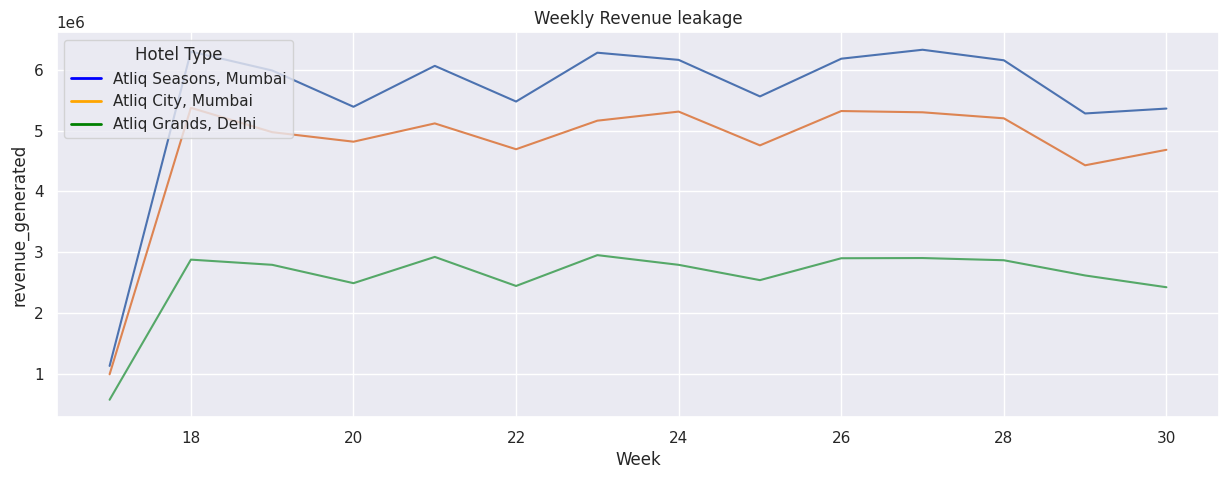

In [91]:
from matplotlib.lines import Line2D

fig,ax=plt.subplots(figsize=(15,5))
ax=sns.lineplot(x=weekly_revenues.week,y=weekly_revenues.revenue_generated)
ax=sns.lineplot(x=weekly_revenues1.week,y=weekly_revenues.revenue_realized)
ax=sns.lineplot(x=weekly_revenues2.week,y=weekly_revenues2.revenue_realized)
ax.set_title("Weekly Revenue leakage")
ax.set_xlabel("Week")

custom_legend = [
    Line2D([0], [0], color='blue', lw=2, label='Atliq Seasons, Mumbai'),
    Line2D([0], [0], color='orange', lw=2, label='Atliq City, Mumbai'),
    Line2D([0], [0], color='green', lw=2, label='Atliq Grands, Delhi')
]

ax.legend(handles=custom_legend, loc='upper left', title='Hotel Type')
plt.show()

In [92]:
fact_aggregated_bookings.query("property_id==17564")

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy_percentage,check_in_day,check_in_month,property_with_city,category
23,17564,2022-05-01,RT1,9,16,56.25,Sunday,May,"Atliq Seasons, Mumbai",Business
43,17564,2022-05-01,RT2,25,40,62.50,Sunday,May,"Atliq Seasons, Mumbai",Business
67,17564,2022-05-01,RT3,16,24,66.67,Sunday,May,"Atliq Seasons, Mumbai",Business
86,17564,2022-05-01,RT4,9,17,52.94,Sunday,May,"Atliq Seasons, Mumbai",Business
124,17564,2022-05-02,RT1,7,16,43.75,Monday,May,"Atliq Seasons, Mumbai",Business
...,...,...,...,...,...,...,...,...,...,...
9085,17564,2022-07-30,RT4,8,17,47.06,Saturday,July,"Atliq Seasons, Mumbai",Business
9124,17564,2022-07-31,RT1,8,16,50.00,Sunday,July,"Atliq Seasons, Mumbai",Business
9144,17564,2022-07-31,RT2,19,40,47.50,Sunday,July,"Atliq Seasons, Mumbai",Business
9174,17564,2022-07-31,RT3,11,24,45.83,Sunday,July,"Atliq Seasons, Mumbai",Business


In [93]:
weekly_revenues["adr"]=weekly_revenues["revenue_realized"]/weekly_revenues["successful_bookings"]
weekly_revenues["revenue_leakage"]=weekly_revenues["revenue_generated"]-weekly_revenues["revenue_realized"]

In [94]:
revenue_leakage.name="revenue_leakage"

In [95]:
kpi_df=kpi_df.merge(revenue_leakage,left_on="property_id",right_on=revenue_leakage.index)

In [96]:
kpi_df.drop(columns="cluster",inplace=True)

**End**

Modelling data for Tableau


In [97]:
from google.colab import files

In [98]:
# kpi_df.to_csv("kpis.csv")
# files.download("kpis.csv")

In [99]:
kpi_df.head()

,property_id,revenue_realized,adr,revpar,alos,average_ratings,booking_perc_RT1,booking_perc_RT2,booking_perc_RT3,booking_perc_RT4,revenue_perc_RT1,revenue_perc_RT2,revenue_perc_RT3,revenue_perc_RT4,cancellation_rate,no_show_rate,occupancy_percentage,revenue_leakage
0,16558,36061172,"11,437.10","7,537.87",1.43,4.25,36.22,42.06,15.16,6.57,25.14,40.80,20.10,13.97,25.06,4.92,67.70,"27,478,486.47"
1,16559,118448418,"16,141.78","10,640.35",1.42,4.32,25.01,33.59,26.51,14.90,14.96,28.15,29.98,26.92,24.61,5.01,65.98,"91,990,853.74"
2,16560,54932178,"11,705.13","6,285.15",1.41,3.01,36.18,35.50,21.03,7.29,24.65,33.63,26.69,15.04,24.12,4.75,53.57,"64,752,084.45"
3,16561,57933400,"13,113.04","8,626.18",1.43,4.28,24.81,32.55,29.00,13.65,15.32,27.43,33.11,24.14,25.51,4.62,65.79,"46,315,438.70"
4,16562,56437570,"11,709.04","6,259.71",1.44,3.07,31.14,43.63,18.78,6.45,21.25,41.09,23.93,13.74,25.27,5.44,54.19,"66,791,536.19"


In [100]:
wide_df=kpi_df[["property_id","booking_perc_RT1",	"booking_perc_RT2",
        "booking_perc_RT3",	"booking_perc_RT4",	]]
long_df=wide_df.melt(id_vars="property_id",var_name="room_type",value_name="booking")
long_df["room_type"]=long_df["room_type"].map({
    "booking_perc_RT1":"Standard",
    "booking_perc_RT2":"Elite",
    "booking_perc_RT3":"Premium",
    "booking_perc_RT4":"Presidential"
})


#
wide_df_revenue=kpi_df[["property_id","revenue_perc_RT1"	,"revenue_perc_RT2",
        "revenue_perc_RT3","revenue_perc_RT4"]]
long_df_revenue=wide_df_revenue.melt(id_vars="property_id",var_name="room_type",value_name="revenue")
long_df_revenue['room_type']=long_df_revenue['room_type'].map({
    "revenue_perc_RT1":"Standard",
    "revenue_perc_RT2":"Elite",
    "revenue_perc_RT3":"Premium",
    "revenue_perc_RT4":"Presidential"
})

long_df=long_df.merge(long_df_revenue,on=["property_id","room_type"])


In [101]:
long_df.head()

,property_id,room_type,booking,revenue
0,16558,Standard,36.22,25.14
1,16559,Standard,25.01,14.96
2,16560,Standard,36.18,24.65
3,16561,Standard,24.81,15.32
4,16562,Standard,31.14,21.25


In [102]:
# long_df.to_csv("room_wise_info.csv")
# files.download("room_wise_info.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [103]:
#booking platform data


In [122]:
wide_df=fact_bookings.groupby(["property_id","booking_platform"])["booking_id"].count().unstack()
wide_df.reset_index(inplace=True)
long_df=pd.melt(wide_df,id_vars="property_id",var_name="booking_platform",value_name="bookings")
long_df.head()

temp1=fact_bookings.groupby(["property_id","booking_platform"])["ratings_given"].mean().unstack()
temp1.reset_index(inplace=True)
long_df1=pd.melt(temp1,id_vars="property_id",var_name="booking_platform",value_name="ratings")

long_df=long_df.merge(long_df1,on=["property_id","booking_platform"])

temp2=fact_bookings.groupby(["property_id","booking_platform"])["revenue_realized"].sum().unstack()
temp2=temp2.divide(temp2.sum(axis=1),axis=0)*100
temp2.reset_index(inplace=True)
long_df2=pd.melt(temp2,id_vars="property_id",var_name="booking_platform",value_name="revenue")

long_df=long_df.merge(long_df2,on=["property_id","booking_platform"])

temp3=fact_bookings.query("booking_status=='Cancelled'").groupby(["property_id","booking_platform"])["booking_id"].count().unstack()
temp3=temp3.divide(temp3.sum(axis=1),axis=0)*100
temp3.reset_index(inplace=True)
long_df3=pd.melt(temp3,id_vars="property_id",var_name="booking_platform",value_name="cancellation")

long_df=long_df.merge(long_df3,on=["property_id","booking_platform"])

temp4=fact_bookings.query("booking_status=='No Show'").groupby(["property_id","booking_platform"])["booking_id"].count().unstack()
temp4=temp4.divide(temp4.sum(axis=1),axis=0)*100
temp4.reset_index(inplace=True)
long_df4=pd.melt(temp4,id_vars="property_id",var_name="booking_platform",value_name="no_show")

long_df=long_df.merge(long_df4,on=["property_id","booking_platform"])

In [126]:
long_df.rename(columns={"reveue":"revenue percentage","cancellation":"cancellation rate","no_show":"no show rate","revenue":"revenue percentage"},inplace=True)
long_df

,property_id,booking_platform,bookings,ratings,revenue percentage,cancellation rate,no show rate
0,16558,direct offline,165,4.18,5.07,5.57,7.74
1,16559,direct offline,364,4.43,4.87,5.26,4.89
2,16560,direct offline,252,2.93,5.30,5.74,5.83
3,16561,direct offline,227,4.27,5.38,5.41,4.41
4,16562,direct offline,221,3.08,4.59,4.11,6.49
...,...,...,...,...,...,...,...
170,19559,tripster,360,3.07,7.65,8.07,7.73
171,19560,tripster,435,4.33,7.32,7.61,7.81
172,19561,tripster,436,3.06,8.07,7.21,7.21
173,19562,tripster,365,4.28,6.29,6.08,6.27


In [127]:
# long_df.to_csv("booking_platform_data.csv")
# files.download("booking_platform_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Daily booking trend data

In [166]:
temp=fact_bookings.query("property_id==16558").groupby("check_in_date")["booking_id"].count()
temp=temp.to_frame()
temp.rename(columns={"booking_id":16558},inplace=True)
temp

for i in fact_aggregated_bookings.property_id.unique():
  if i!=16558:
    temp1=fact_bookings.query("property_id==@i").groupby("check_in_date")["booking_id"].count()
    temp=temp.merge(temp1.to_frame(),left_on="check_in_date",right_on=temp1.index)
    temp.rename(columns={"booking_id":i},inplace=True)


In [167]:
temp=temp.melt(id_vars="check_in_date",var_name="property_id",value_name="total_bookings")

In [168]:
# temp.to_csv("daily_booking_trend.csv",index=False)
# files.download("daily_booking_trend.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [169]:
temp=fact_bookings.query("property_id==16558").groupby("check_in_date")["revenue_realized"].sum()
temp=temp.to_frame()
temp.rename(columns={"revenue_realized":16558},inplace=True)
temp

for i in fact_aggregated_bookings.property_id.unique():
  if i!=16558:
    temp1=fact_bookings.query("property_id==@i").groupby("check_in_date")["revenue_realized"].sum()
    temp=temp.merge(temp1.to_frame(),left_on="check_in_date",right_on=temp1.index)
    temp.rename(columns={"revenue_realized":i},inplace=True)

temp=temp.melt(id_vars="check_in_date",var_name="property_id",value_name="total_revenue")

In [170]:
# temp.to_csv("daily_revenue_trend.csv",index=False)
# files.download("daily_revenue_trend.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [135]:
fact_bookings.property_id.unique()

array([16558, 16559, 16560, 16561, 16562, 16563, 17558, 17559, 17560,
       17561, 17562, 17563, 18558, 18559, 18560, 18561, 18562, 18563,
       19558, 19559, 19560, 19561, 19562, 19563, 17564])

In [182]:
#Weekday and weekend occupancy
weekend_occupancy=fact_aggregated_bookings.query("(check_in_day =='Sunday') or (check_in_day=='Saturday')").groupby("property_id")["occupancy_percentage"].mean()
weekday_occupancy=fact_aggregated_bookings.query("(check_in_day!='Sunday') and (check_in_day!='Saturday')").groupby("property_id")["occupancy_percentage"].mean()

occupancy_df=pd.concat([weekend_occupancy,weekday_occupancy],axis=1)
occupancy_df.columns=["weekend_occupancy","weekday_occupancy"]

In [183]:
occupancy_df.reset_index(inplace=True)
occupancy_df=occupancy_df.melt(id_vars="property_id",var_name="type",value_name="occuancy")

In [184]:
occupancy_df

,property_id,type,occuancy
0,16558,weekend_occupancy,86.02
1,16559,weekend_occupancy,84.04
2,16560,weekend_occupancy,68.21
3,16561,weekend_occupancy,84.67
4,16562,weekend_occupancy,67.61
5,16563,weekend_occupancy,83.86
6,17558,weekend_occupancy,68.57
7,17559,weekend_occupancy,84.11
8,17560,weekend_occupancy,67.92
9,17561,weekend_occupancy,84.39


In [185]:
occupancy_df.to_csv("occupancy_data.csv",index=False)
files.download("occupancy_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [152]:
fact_aggregated_bookings.head(2)

,property_id,check_in_date,room_category,successful_bookings,capacity,occupancy_percentage,check_in_day,check_in_month,property_with_city,category
0,16559,2022-05-01,RT1,25,30,83.33,Sunday,May,"Atliq Exotica, Mumbai",Luxury
1,19562,2022-05-01,RT1,28,30,93.33,Sunday,May,"Atliq Bay, Bangalore",Luxury


In [105]:
fact_bookings.head(1)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,has_rated,revenue_leakage
0,May012216558RT11,16558,2022-04-27,2022-05-01,2022-05-02,3,RT1,direct online,1.00,Checked Out,10010,10010,1,0
